In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import sys

from GRB_class import *

sys.path.insert(0, '.')
torch.set_default_dtype(torch.float64)
device = torch.device('cpu')
print(f'Device: {device}')
print(f'Default dtype: {torch.get_default_dtype()}')

Device: cpu
Default dtype: torch.float64


# Traditional method example

## Finite-Difference Discretization of the Heat Equation

We start from the 1D heat equation:

$
\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}
$

---

### Discretization

We define a grid in space and time:

- $x_i = i\,\Delta x$
- $t^n = n\,\Delta t$
- $u(x_i, t^n) \equiv u_i^n$

---

### Time derivative (forward difference)

$\frac{\partial u}{\partial t} \approx \frac{u_i^{n+1} - u_i^n}{\Delta t}$

---

### Second spatial derivative (central difference)

$\frac{\partial^2 u}{\partial x^2}\approx\frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{(\Delta x)^2}$

---

### Plug into the PDE

$\frac{u_i^{n+1} - u_i^n}{\Delta t}=\alpha \frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{(\Delta x)^2}$

---

### Solve for the update rule

$u_i^{n+1}=u_i^n+\alpha \frac{\Delta t}{(\Delta x)^2}\left( u_{i+1}^n - 2u_i^n + u_{i-1}^n\right) $

Define:

$r = \alpha \frac{\Delta t}{(\Delta x)^2}$

so that:

$u_i^{n+1}=u_i^n + r \left(u_{i+1}^n - 2u_i^n + u_{i-1}^n\right)$

---

### Python implementation

```python
u_new[i] = u[i] + r * (u[i+1] - 2*u[i] + u[i-1])

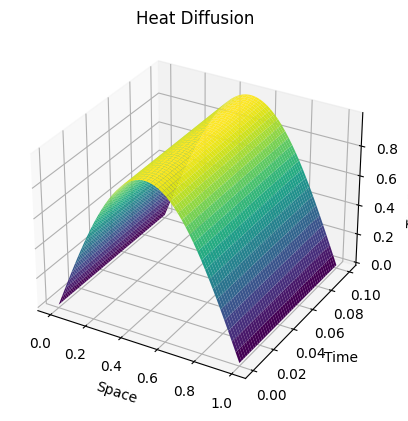

In [ ]:
# parameters
L = 1.0        # length of domain
T = 0.1        # total time
nx = 50        # spatial points
nt = 500       # time steps
alpha = 0.001   # diffusion coefficient

dx = L / (nx - 1)
dt = T / nt

# stability condition
r = alpha * dt / dx**2

# grid
x = np.linspace(0, L, nx)
u = np.sin(np.pi * x)  # initial condition

# plot result in 3D for time and space using a surface plot
X, T = np.meshgrid(x, np.linspace(0, T, nt))
U = np.zeros((nt, nx))
u = np.sin(np.pi * x)  # reset initial condition
for n in range(nt):
    U[n, :] = u
    u_new = u.copy()
    for i in range(1, nx - 1):
        u_new[i] = u[i] + r * (u[i+1] - 2*u[i] + u[i-1])
    u = u_new   
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, T, U, cmap='viridis')
ax.set_xlabel('Space')  
ax.set_ylabel('Time')
ax.set_zlabel('Temperature')
ax.set_title('Heat Diffusion')
plt.show()


# Our problem

In [4]:
# setup up directory for saving/loading simulation data
savedir = "./grb_TEST/"

if not os.path.isdir(savedir):
    os.mkdir(savedir)

# filenames
save_fn = savedir + "GRB"

In [5]:
DIM = 1

GRB_obj = GRB_model(DIM,logger=None)

# set some data
init_cond_u_str = "CoefficientFunction( exp(-(x-3.5)**2) )"
bdy_cond_u_str  = "CoefficientFunction( 0.0 )"
GRB_data = {'dim' : DIM, 'FE_degree' : 1, 'linearsolve' : True, \
            'time_scale_u' : 1.0, 'Lorentz_factor' : 1.0, \
            'init_cond_u' : init_cond_u_str, 'bdy_cond_u' : bdy_cond_u_str, \
            'init_time' : 0, 'num_steps' : 50, 'final_time' : 0.2, 'dt' : []}

GRB_obj.set_data(prob_data=GRB_data,filename=savedir + "GRB_data")

In [ ]:
# --------------------------------------------------
# Mesh: x in (2,6) (interval)
# --------------------------------------------------
REF_factor = 10
max_mesh_size = 0.1 / REF_factor

GRB_obj.define_interval_mesh(2.0, 6.0, max_mesh_size)

GRB_obj.define_finite_element_spaces()

('left', 'right')


In [7]:
# --------------------------------------------------
# Physical parameters (examples)
# --------------------------------------------------
logdiffcoef = 0.5
t_esc = 5.0

def t_acc(t):
    return 1.0

def a_cool(t):
    return 0.2

GRB_obj.t_val.Set(0.0)

# Time-dependent coefficient functions (updated in loop)
C_coef = CF( (1/t_esc) + (1/t_acc(GRB_obj.t_val)) - a_cool(GRB_obj.t_val)*exp(x) )
B_coef = CF( (1/t_acc(GRB_obj.t_val)) - a_cool(GRB_obj.t_val)*exp(x) - logdiffcoef )
q_CF = CF(0) # for now

In [ ]:
class PINN(nn.Module):
    def __init__(self, n_hidden=128, n_layers=5):
        super().__init__()
        layers = []
        layers.append(nn.Linear(2, n_hidden)); layers.append(nn.Tanh())
        for _ in range(n_layers - 1):
            layers.append(nn.Linear(n_hidden, n_hidden)); layers.append(nn.Tanh())
        layers.append(nn.Linear(n_hidden, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x, t):
        # x = log(gamma)
        input = torch.cat([x, t], dim=1)
        return self.net(input)


In [ ]:
model = PINN().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'PINN: 5x128, tanh, {n_params:,} params, {next(model.parameters()).dtype}')

In [ ]:
COLLOC_POINTS = 400

# THESE INITIAL CONDITIONS ARE FIXED and NEED TO BE DEFINED ONCE
U0_value = 0.0
x_ic_value = 0.0
t_ic_value = 0.0
# Define ONCE (outside training loop): fixed IC constraint points
x0 = torch.tensor([[x_ic_value]], dtype=torch.float32, device=device)   # or many x values
t0 = torch.tensor([[t_ic_value]], dtype=torch.float32, device=device)   # usually 0
u0 = torch.tensor([[U0_value]],    dtype=torch.float32, device=device)  # target value
lambda_ic = 10.0  # tune this weight

In [ ]:
def injection_source(x, p=2.5):
    q = torch.zeros_like(x)
    q = -p * x 
    return q

def compute_pinn_loss(model, n_colloc=COLLOC_POINTS):
    # get the grid and make it torch tensor
    x_grid = torch.tensor(GRB_obj.x_vec, device=device)
    t_grid = torch.tensor(GRB_obj.time_vec, device=device)
    x_grid.requires_grad_(True)
    t_grid.requires_grad_(True)

    U = model(x_grid, t_grid)
    dU_dx = torch.autograd.grad(U, x_grid, grad_outputs=torch.ones_like(U), create_graph=True)[0]
    d2U_dx2 = torch.autograd.grad(dU_dx, x_grid, grad_outputs=torch.ones_like(dU_dx), create_graph=True)[0]
    dU_dt = torch.autograd.grad(U, t_grid, grad_outputs=torch.ones_like(U), create_graph=True)[0]

    q = injection_source(x_grid)
    C_coef = 1/t_esc + 1/t_acc(t_grid) - a_cool(t_grid)*exp(x_grid)
    B_coef = 1/t_acc(t_grid) - a_cool(t_grid)*exp(x_grid) - logdiffcoef
    dB_dx = - a_cool(t_grid)*exp(x_grid)
    residuals = dU_dt - q + C_coef*U + B_coef*dU_dx + dB_dx*U - logdiffcoef*d2U_dx2 
    #!!!!!!! ADD Initial condition residual to the loss to penalize

    # compute the loss and add a penalization for the initial condition
    L_pde = (residuals**2).mean()

    # IC loss (always active, same fixed tensors every step)
    u_pred_ic = model(x0, t0)
    L_ic = ((u_pred_ic - u0)**2).mean()

    loss = L_pde + lambda_ic * L_ic

    return loss
